In [1]:
%pip install torchmetrics pycocotools

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import json
from PIL import Image
from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import time
import torch.backends.cudnn as cudnn
cudnn.benchmark = True
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
from torch.utils.data import WeightedRandomSampler
import numpy as np



DataSet 클래스

In [4]:
class PillDataset(Dataset):
    def __init__(self, img_dir, json_dir, transforms=None):
        self.img_dir = img_dir
        self.json_dir = json_dir
        self.transforms = transforms
        self.img_files = [f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))]

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        json_path = os.path.join(
            self.json_dir,
            os.path.splitext(img_name)[0] + ".json"
        )

        # 이미지 로드
        img = Image.open(img_path).convert("RGB")
        img = np.array(img)

        boxes = []
        labels = []

        # JSON 로드
        if os.path.exists(json_path):
            with open(json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            for ann in data.get("annotations", []):
                x, y, w, h = ann["bbox"]
                # [xmin, ymin, xmax, ymax] 형식 (pascal_voc)
                boxes.append([x, y, x + w, y + h])
                labels.append(ann["category_id"])

        if self.transforms:
            transformed = self.transforms(
                image=img,
                bboxes=boxes,
                class_labels=labels
            )
            
            img = transformed["image"]
            
            new_boxes = np.array(transformed["bboxes"])
            new_labels = np.array(transformed["class_labels"])
        else:
            img = torch.as_tensor(img).permute(2, 0, 1).float() / 255.0
            new_boxes = np.array(boxes)
            new_labels = np.array(labels)

        target = {}
        if len(new_boxes) > 0:
            target["boxes"] = torch.as_tensor(new_boxes, dtype=torch.float32)
            target["labels"] = torch.as_tensor(new_labels, dtype=torch.int64)
        else:
            target["boxes"] = torch.zeros((0, 4), dtype=torch.float32)
            target["labels"] = torch.zeros((0,), dtype=torch.int64)

        target["image_id"] = torch.tensor([idx])
        
        return img, target

    def __len__(self):
        return len(self.img_files)

DataLoader 설정

In [12]:
import pickle

def get_transform(train=True):
    transforms = []
    
    if train: #학습 데이터에만 적용될 수 있도록
        return A.Compose([
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0, p=0.3),
            A.LongestMaxSize(max_size=800),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(
            format='pascal_voc',
            label_fields=['class_labels'],
            clip=True,
            min_area=2.0,
            min_visibility=0.1
        ))
    else: #val 데이터에 대한 전처리내용
        return A.Compose([
            A.LongestMaxSize(max_size=800),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(
            format='pascal_voc',
            label_fields=['class_labels']
        ))


full_dataset = PillDataset(
    img_dir=r'C:\Users\thsdu\Desktop\beg_project\Datas\fixed_data\aug_sampling_data\images',
    json_dir=r'C:\Users\thsdu\Desktop\beg_project\Datas\fixed_data\aug_sampling_data\annotations',
    transforms=get_transform()
)

indices = list(range(len(full_dataset)))
train_indices, val_indices = train_test_split(indices, test_size=0.2, random_state=42)

train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)

class_counts = {
    0:149, 1:231, 2:274, 3:135, 4:226, 5:342, 6:224, 7:308,
    8:279, 9:335, 10:330, 11:256, 12:220, 13:915, 14:557,
    15:814, 16:794, 17:248, 18:304, 19:313, 20:317, 21:332,
    22:201, 23:321, 24:293, 25:574, 26:344, 27:283, 28:201,
    29:250, 30:340, 31:245, 32:202, 33:329, 34:277, 35:338,
    36:309, 37:298, 38:194, 39:158, 40:329, 41:187, 42:188,
    43:564, 44:319, 45:280, 46:303, 47:304, 48:191, 49:198,
    50:301, 51:319, 52:570, 53:557, 54:258, 55:315
}

# inverse frequency
class_weights = {k: 1.0 / v for k, v in class_counts.items()}

def get_image_weight(target):
    labels = target['labels'].tolist()
    
    if len(labels) == 0:
        return 0.1
    
    weights = [class_weights[l] for l in labels]
    return max(weights)

if os.path.exists("sample_weights.pkl"):
    with open("sample_weights.pkl", "rb") as f:
        sample_weights = pickle.load(f)
else:
    sample_weights = []
    for i in range(len(train_dataset)):
        _, target = train_dataset[i]
        w = get_image_weight(target)
        sample_weights.append(w)

    with open("sample_weights.pkl", "wb") as f:
        pickle.dump(sample_weights, f)
        
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)




def collate_fn(batch):
    return tuple(zip(*batch))


train_loader = DataLoader(
    train_dataset, 
    batch_size=4,          
    shuffle=False, #sampler 쓰기때문에
    sampler=sampler,
    num_workers=0,         
    collate_fn=collate_fn  
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=2, 
    shuffle=False, 
    num_workers=0, 
    collate_fn=collate_fn
)

In [6]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm

def evaluate(model, data_loader, device):
    model.eval() # 평가 모드 (Loss 계산이 아니라 예측값을 내뱉음)
    metric = MeanAveragePrecision(iou_type="bbox")
    
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating"):
            images = list(img.to(device) for img in images)
            outputs = model(images) # 예측 결과 [{boxes, scores, labels}, ...]
            
            # targets를 device로 옮기고 Metric 형식에 맞게 변환
            res_targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            filtered_outputs = []

            for o in outputs:
                boxes = o['boxes']
                scores = o['scores']
                labels = o['labels']

                valid_boxes = []
                valid_scores = []
                valid_labels = []

                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box

                    if x2 <= x1 or y2 <= y1:
                        continue
                    
                    if score < 0.05:
                        continue
                    valid_boxes.append(box)
                    valid_scores.append(score)
                    valid_labels.append(label)

                if len(valid_boxes) == 0:
                    filtered_outputs.append({
                        "boxes": torch.zeros((0, 4), device=device),
                        "scores": torch.zeros((0,), device=device),
                        "labels": torch.zeros((0,), dtype=torch.int64, device=device)
                    })
                else:
                    filtered_outputs.append({
                        "boxes": torch.stack(valid_boxes),
                        "scores": torch.stack(valid_scores),
                        "labels": torch.stack(valid_labels),
                    })

            res_outputs = filtered_outputs
            
            metric.update(res_outputs, res_targets)

    # 모든 배치 계산 후 최종 mAP 산출
    result = metric.compute()
    
    print("Validation Performance")
    print(f"mAP (IoU=0.50:0.95): {result['map']:.4f}")
    print(f"mAP@50: {result['map_50']:.4f}")
    print(f"mAP@75: {result['map_75']:.4f}")

    
    return result

In [14]:


device = 'cuda' if torch.cuda.is_available() else 'cpu'

weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

# 배경 포함 클래스수
num_classes = 57 
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes=num_classes)

checkpoint_path = r"C:\Users\thsdu\pill_model_ep10.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)
model.train()

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)

def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0
    start_time = time.time()

    for i, batch in enumerate(data_loader):
        images, targets = batch
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        

        losses = sum(loss for loss in loss_dict.values())

        # 3. 역전파 및 최적화 (Backward & Optimizer Step)
        optimizer.zero_grad()
        losses.backward()
        # 그래디언트가 과도하게 커지지 않도록 제한검
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += losses.item()

        # 10번의 반복마다 현재 상황 출력
        if i % 50 == 0:
            print(f"Epoch [{epoch}] Iter [{i}/{len(data_loader)}] "
                  f"Loss: {losses.item():.4f} "
                  f"(RPN_Obj: {loss_dict['loss_objectness']:.3f}, "
                  f"RPN_Reg: {loss_dict['loss_rpn_box_reg']:.3f}, "
                  f"Box: {loss_dict['loss_box_reg']:.3f})")

    avg_loss = total_loss / len(data_loader)
    elapsed = time.time() - start_time
    print(f"==> Epoch {epoch} 평균 Loss: {avg_loss:.4f} | 소요 시간: {elapsed:.1f}s")
    return avg_loss


num_epochs = 15
loss_history = []
print(f"Model is on: {next(model.parameters()).device}")

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)

for epoch in range(1, num_epochs+1):
    epoch_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)
    loss_history.append(epoch_loss)

    scheduler.step()

    val_stats = evaluate(model, val_loader, device)

    # 5 에폭마다 가중치 저장 (백업용)
    if epoch % 5 == 0:
         torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'mAP': val_stats['map'],
        }, f"pill_model_ep{epoch}.pth")

print("모든 학습이 완료됨")

Model is on: cuda:0
Epoch [1] Iter [0/1566] Loss: 0.4344 (RPN_Obj: 0.012, RPN_Reg: 0.002, Box: 0.144)
Epoch [1] Iter [50/1566] Loss: 0.2534 (RPN_Obj: 0.004, RPN_Reg: 0.001, Box: 0.123)
Epoch [1] Iter [100/1566] Loss: 0.3047 (RPN_Obj: 0.000, RPN_Reg: 0.002, Box: 0.107)
Epoch [1] Iter [150/1566] Loss: 0.2660 (RPN_Obj: 0.000, RPN_Reg: 0.002, Box: 0.113)
Epoch [1] Iter [200/1566] Loss: 0.2574 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.148)
Epoch [1] Iter [250/1566] Loss: 0.1170 (RPN_Obj: 0.003, RPN_Reg: 0.001, Box: 0.070)
Epoch [1] Iter [300/1566] Loss: 0.2690 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.155)
Epoch [1] Iter [350/1566] Loss: 0.2361 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.117)
Epoch [1] Iter [400/1566] Loss: 0.2936 (RPN_Obj: 0.002, RPN_Reg: 0.004, Box: 0.137)
Epoch [1] Iter [450/1566] Loss: 0.1733 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.093)
Epoch [1] Iter [500/1566] Loss: 0.2396 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.112)
Epoch [1] Iter [550/1566] Loss: 0.2209 (RPN_Obj: 0.000, RPN

Evaluating: 100%|██████████| 783/783 [01:36<00:00,  8.13it/s]


Validation Performance
mAP (IoU=0.50:0.95): 0.7643
mAP@50: 0.9458
mAP@75: 0.9339
Epoch [2] Iter [0/1566] Loss: 0.1657 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.106)
Epoch [2] Iter [50/1566] Loss: 0.2356 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.129)
Epoch [2] Iter [100/1566] Loss: 0.1185 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.078)
Epoch [2] Iter [150/1566] Loss: 0.1560 (RPN_Obj: 0.001, RPN_Reg: 0.001, Box: 0.075)
Epoch [2] Iter [200/1566] Loss: 0.1307 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.084)
Epoch [2] Iter [250/1566] Loss: 0.1595 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.082)
Epoch [2] Iter [300/1566] Loss: 0.1306 (RPN_Obj: 0.001, RPN_Reg: 0.001, Box: 0.076)
Epoch [2] Iter [350/1566] Loss: 0.1161 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.073)
Epoch [2] Iter [400/1566] Loss: 0.1561 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.099)
Epoch [2] Iter [450/1566] Loss: 0.1569 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.105)
Epoch [2] Iter [500/1566] Loss: 0.1296 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.083

Evaluating: 100%|██████████| 783/783 [01:52<00:00,  6.94it/s]


Validation Performance
mAP (IoU=0.50:0.95): 0.8123
mAP@50: 0.9578
mAP@75: 0.9512
Epoch [3] Iter [0/1566] Loss: 0.1839 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.090)
Epoch [3] Iter [50/1566] Loss: 0.1617 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.112)
Epoch [3] Iter [100/1566] Loss: 0.1400 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.085)
Epoch [3] Iter [150/1566] Loss: 0.1201 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.074)
Epoch [3] Iter [200/1566] Loss: 0.0978 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.056)
Epoch [3] Iter [250/1566] Loss: 0.1269 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.074)
Epoch [3] Iter [300/1566] Loss: 0.1067 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.065)
Epoch [3] Iter [350/1566] Loss: 0.1035 (RPN_Obj: 0.001, RPN_Reg: 0.001, Box: 0.068)
Epoch [3] Iter [400/1566] Loss: 0.1478 (RPN_Obj: 0.002, RPN_Reg: 0.001, Box: 0.082)
Epoch [3] Iter [450/1566] Loss: 0.1333 (RPN_Obj: 0.003, RPN_Reg: 0.001, Box: 0.072)
Epoch [3] Iter [500/1566] Loss: 0.1165 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.076

...

Validation Performance
mAP (IoU=0.50:0.95): 0.9206
mAP@50: 0.9720
mAP@75: 0.9690
Epoch [14] Iter [0/1566] Loss: 0.0284 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.018)
Epoch [14] Iter [50/1566] Loss: 0.0497 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.025)
Epoch [14] Iter [100/1566] Loss: 0.0481 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.020)
Epoch [14] Iter [150/1566] Loss: 0.1083 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.046)
Epoch [14] Iter [200/1566] Loss: 0.0343 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.017)
Epoch [14] Iter [250/1566] Loss: 0.0496 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.022)
Epoch [14] Iter [300/1566] Loss: 0.0697 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.029)
Epoch [14] Iter [350/1566] Loss: 0.0557 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.032)
Epoch [14] Iter [400/1566] Loss: 0.0524 (RPN_Obj: 0.002, RPN_Reg: 0.000, Box: 0.022)
Epoch [14] Iter [450/1566] Loss: 0.0460 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.025)
Epoch [14] Iter [500/1566] Loss: 0.0421 (RPN_Obj: 0.000, RPN_Reg: 0.000,

Evaluating: 100%|██████████| 783/783 [01:38<00:00,  7.95it/s]


Validation Performance
mAP (IoU=0.50:0.95): 0.9197
mAP@50: 0.9719
mAP@75: 0.9691
Epoch [15] Iter [0/1566] Loss: 0.0438 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.022)
Epoch [15] Iter [50/1566] Loss: 0.0429 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.023)
Epoch [15] Iter [100/1566] Loss: 0.0551 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.030)
Epoch [15] Iter [150/1566] Loss: 0.0622 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.037)
Epoch [15] Iter [200/1566] Loss: 0.0754 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.043)
Epoch [15] Iter [250/1566] Loss: 0.0828 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.043)
Epoch [15] Iter [300/1566] Loss: 0.0412 (RPN_Obj: 0.000, RPN_Reg: 0.001, Box: 0.021)
Epoch [15] Iter [350/1566] Loss: 0.0326 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.019)
Epoch [15] Iter [400/1566] Loss: 0.0429 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.025)
Epoch [15] Iter [450/1566] Loss: 0.0431 (RPN_Obj: 0.000, RPN_Reg: 0.000, Box: 0.026)
Epoch [15] Iter [500/1566] Loss: 0.0481 (RPN_Obj: 0.000, RPN_Reg: 0.001,

Evaluating: 100%|██████████| 783/783 [01:43<00:00,  7.56it/s]


Validation Performance
mAP (IoU=0.50:0.95): 0.9225
mAP@50: 0.9716
mAP@75: 0.9696
모든 학습이 완료됨


테스트 이미지

모드 dict에서 가중치를 성공적으로 불러왔습니다.


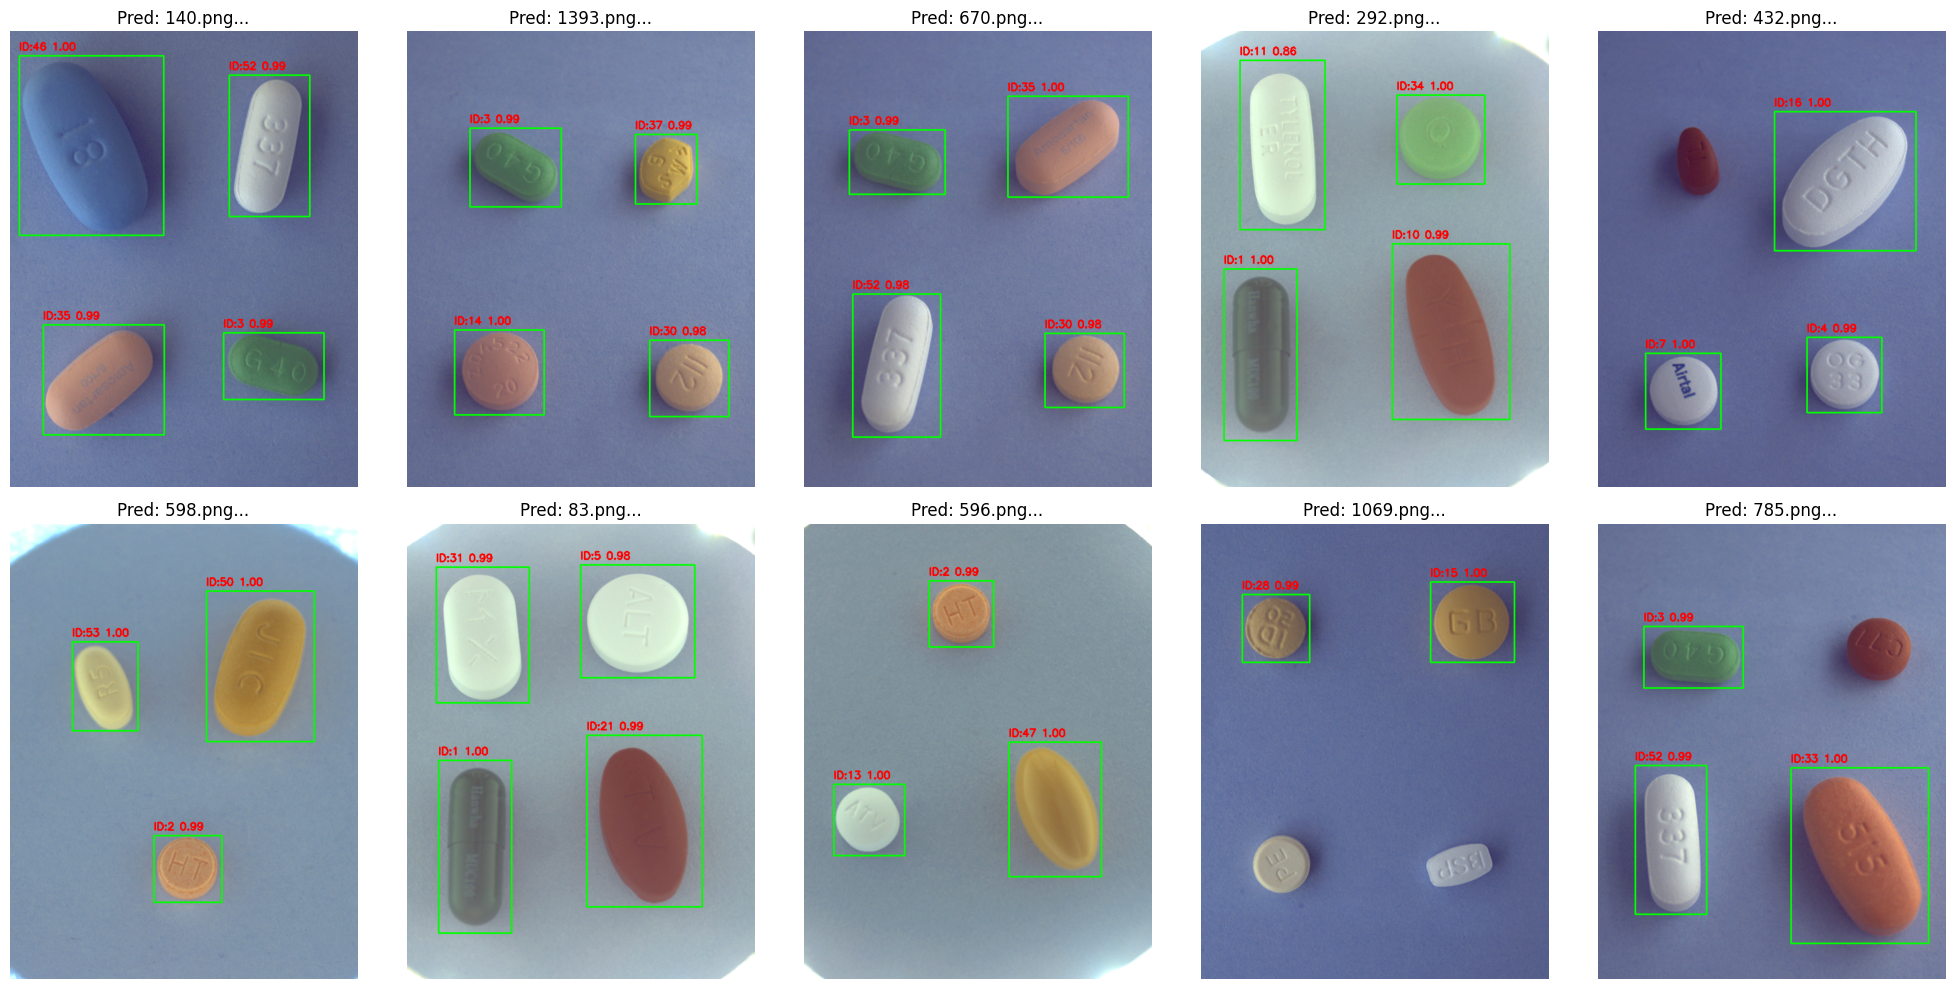

In [14]:
import matplotlib.pyplot as plt
import random

def load_model(checkpoint_path, num_classes, device):
    model = fasterrcnn_resnet50_fpn(pretrained=False)
    
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print("모드 dict에서 가중치를 성공적으로 불러왔습니다.")
    else:
        model.load_state_dict(checkpoint)
        print("가중치를 성공적으로 불러왔습니다.")

    model.to(device)
    model.eval()
    return model

def get_test_transform():
    return A.Compose([
        A.LongestMaxSize(max_size=800),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
num_classes = 57
model = load_model(r"C:\Users\thsdu\pill_model_CLAHE_ep15.pth", num_classes, device)

def run_inference_on_folder(model, folder_path, device, num_samples=10):
    # 폴더 내 이미지 파일 찾기
    valid_exts = ('.png', '.jpg', '.jpeg', '.JPG', '.PNG')
    img_files = [f for f in os.listdir(folder_path) if f.endswith(valid_exts)]
    
    if len(img_files) < num_samples:
        num_samples = len(img_files)
    
    selected_files = random.sample(img_files, num_samples)
    transform = get_test_transform()
    
    plt.figure(figsize=(20, 10))

    for i, file_name in enumerate(selected_files):
        img_path = os.path.join(folder_path, file_name)
        
        # 한글 경로 대응 이미지 로드
        img_array = np.fromfile(img_path, np.uint8)
        img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # 모델 입력용 전처리
        transformed = transform(image=img_rgb)
        input_tensor = transformed["image"].to(device).unsqueeze(0)
        
        # 시각화용 도화지 (모델이 본 800 사이즈와 동일하게 맞춤)
        vis_resizer = A.Compose([A.LongestMaxSize(max_size=800)])
        vis_img = vis_resizer(image=img_rgb)["image"]

        # 모델 추론
        with torch.no_grad():
            outputs = model(input_tensor)

        # 결과 추출
        boxes = outputs[0]['boxes'].cpu().numpy()
        scores = outputs[0]['scores'].cpu().numpy()
        labels = outputs[0]['labels'].cpu().numpy()

        # 박스 그리기
        for box, score, label in zip(boxes, scores, labels):
            if score > 0.5: # 신뢰도 임계값
                x1, y1, x2, y2 = box.astype(int)
                cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                text = f"ID:{label} {score:.2f}"
                cv2.putText(vis_img, text, (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        # 출력
        plt.subplot(2, 5, i + 1)
        plt.imshow(vis_img)
        plt.title(f"Pred: {file_name[:10]}...")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

run_inference_on_folder(model, r'C:\Users\thsdu\Desktop\beg_project\sprint_ai_project1_data\test_images', device)
